# Insider Trading Signal Analysis: Cumulative Abnormal Returns Around SEC Form 4 Filings

---

## Abstract

This analysis investigates whether insider trading activity—specifically open-market purchases and sales reported via SEC Form 4 filings—provides predictive signals for future stock price movements. Using an event study methodology, I calculate **Cumulative Abnormal Returns (CAR)** around insider transaction dates to quantify the informational content of these trades.

The analysis covers a **subset of ~90 large-cap U.S. equities** with recent insider purchase activity over a 10-year period, examining thousands of individual insider transactions to determine whether insiders systematically trade before abnormal stock performance.

---

## Academic Foundation

**Primary Reference:**

> Jeng, L. A., Metrick, A., & Zeckhauser, R. (2003). Estimating the returns to insider trading: A performance-evaluation perspective. The Review of Economics and Statistics, 85(2), 453–471.

**Key Extension / Contribution:**

> This analysis extends the methodology by applying path-normalized CAR calculations to modern large-cap equity data, incorporating both pre-event and post-event windows to capture timing precision of insider trades.

---


---

## Section 1: Configuration & Data Loading

### Data Sources

| Source | Description |
|--------|-------------|
| **Stock Prices** | Yahoo Finance (adjusted close prices) |
| **Insider Transactions** | SEC EDGAR Form 4 filings using Edgartools Python Package |
| **Market Benchmark** | VOO (Vanguard S&P 500 ETF) |

In [81]:
# ==============================================================================
# CONFIGURATION & IMPORTS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Display configuration for cleaner output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ==============================================================================
# ANALYSIS PARAMETERS
# ==============================================================================

TICKER = "WELL"                    # Target ticker for single-stock analysis
MARKET_TICKER = "VOO"              # Market benchmark for abnormal returns
DATA_DIR = Path("../data")         # Local data directory

print("=" * 60)
print("INSIDER TRADING ANALYSIS - CONFIGURATION")
print("=" * 60)
print(f"Target Ticker:     {TICKER}")
print(f"Market Benchmark:  {MARKET_TICKER}")
print("=" * 60)

INSIDER TRADING ANALYSIS - CONFIGURATION
Target Ticker:     WELL
Market Benchmark:  VOO


In [82]:
# Load historical stock prices
df_prices = pd.read_parquet(DATA_DIR / "prices" / f"{TICKER}.parquet")

print(f"Stock Price Data: {TICKER}")
print("-" * 40)
print(f"Total Observations:  {len(df_prices):,}")
print(f"Date Range:          {df_prices['date'].min().strftime('%Y-%m-%d')} to {df_prices['date'].max().strftime('%Y-%m-%d')}")
print(f"Price Range:         ${df_prices['adj_close'].min():.2f} - ${df_prices['adj_close'].max():.2f}")
print("-" * 40)

df_prices.head()

Stock Price Data: WELL
----------------------------------------
Total Observations:  2,515
Date Range:          2015-12-28 to 2025-12-26
Price Range:         $28.01 - $208.22
----------------------------------------


,ticker,date,adj_close,volume
0,WELL,2015-12-28,46.11,1167100
1,WELL,2015-12-29,46.78,1910100
2,WELL,2015-12-30,46.65,996300
3,WELL,2015-12-31,46.45,1461800
4,WELL,2016-01-04,46.70,2434100


In [83]:
# Load SEC Form 4 filings
df_forms = pd.read_parquet(DATA_DIR / "SPY" / f"{TICKER}.parquet")

# Separate purchases and sales
df_purchases = df_forms[df_forms["code"] == 'P'].copy()
df_sales = df_forms[df_forms["code"] == 'S'].copy()

print(f"SEC Form 4 Data: {TICKER}")
print("-" * 40)
print(f"Total Transactions:  {len(df_forms):,}")
print(f"Unique Insiders:     {df_forms['insider_name'].nunique()}")
print(f"Purchase Events:     {len(df_purchases):,}")
print(f"Sale Events:         {len(df_sales):,}")
print("-" * 40)

SEC Form 4 Data: WELL
----------------------------------------
Total Transactions:  851
Unique Insiders:     33
Purchase Events:     10
Sale Events:         36
----------------------------------------


---

## Section 2: Transaction Aggregation

### Data Preprocessing Rationale

Insiders often execute multiple transactions on the same day (e.g., buying shares at different prices throughout the trading session). To avoid over-counting events in the event study, we aggregate same-day transactions by the same insider into a single event with:

- **Total shares** = sum of all individual transactions
- **Total value** = sum of all dollar amounts  
- **Price per share** = value-weighted average

In [84]:
def combine_same_day_transactions(df, transaction_type="purchase"):
    """
    Aggregate multiple same-day transactions by the same insider into a single event.
    """
    if df.empty:
        return pd.DataFrame()
    
    grouped = df.groupby(['insider_name', 'reporting_date'])
    
    combined_rows = []
    for (insider, date), group in grouped:
        if len(group) == 1:
            combined_rows.append(group.iloc[0].to_dict())
        else:
            row = group.iloc[0].to_dict()
            row['accession_no'] = 'COMBINED'
            row['shares'] = group['shares'].sum()
            row['value'] = group['value'].sum()
            row['price_per_share'] = row['value'] / row['shares'] if row['shares'] > 0 else 0
            combined_rows.append(row)
    
    return pd.DataFrame(combined_rows)

# Backward compatibility aliases
combine_same_day_purchases = lambda df: combine_same_day_transactions(df, "purchase")
combine_same_day_sales = lambda df: combine_same_day_transactions(df, "sale")

# Aggregate purchases
df_purchases_combined = combine_same_day_transactions(df_purchases, "purchase")

print("Purchase Transaction Aggregation")
print("-" * 40)
print(f"Raw transactions:        {len(df_purchases):,}")
print(f"After aggregation:       {len(df_purchases_combined):,}")
print(f"Transactions combined:   {len(df_purchases) - len(df_purchases_combined):,}")
print("-" * 40)

Purchase Transaction Aggregation
----------------------------------------
Raw transactions:        10
After aggregation:       9
Transactions combined:   1
----------------------------------------


In [85]:
# Aggregate sales using the same methodology
df_sales_combined = combine_same_day_transactions(df_sales, "sale")

print("Sale Transaction Aggregation")
print("-" * 40)
print(f"Raw transactions:        {len(df_sales):,}")
print(f"After aggregation:       {len(df_sales_combined):,}")
print(f"Transactions combined:   {len(df_sales) - len(df_sales_combined):,}")
print("-" * 40)

# Summary statistics
print(f"\nFinal Dataset Summary for {TICKER}:")
print("=" * 40)
print(f"Unique purchase events:  {len(df_purchases_combined):,}")
print(f"Unique sale events:      {len(df_sales_combined):,}")
print("=" * 40)

Sale Transaction Aggregation
----------------------------------------
Raw transactions:        36
After aggregation:       28
Transactions combined:   8
----------------------------------------

Final Dataset Summary for WELL:
Unique purchase events:  9
Unique sale events:      28


---

## Section 3: Visualization - Price History with Insider Activity

### Visualization Strategy

This visualization overlays insider transaction events on the stock price chart to provide intuitive understanding of transaction timing. The color coding by number of concurrent insiders helps identify potential **"clustering" events** where multiple insiders trade simultaneously (which may indicate stronger signals).

| Color | Meaning |
|-------|---------|
| Red | 1 insider trading |
| Orange | 2 insiders trading |
| Green | 3 insiders trading |
| Blue | 4 insiders trading |
| Purple | 5+ insiders trading |

In [86]:
def plot_insider_activity(df_transactions, df_prices, title, years=10):
    """Generate an annotated price chart with insider transaction markers."""
    # Filter to specified time window
    end_date = df_prices['date'].max()
    start_date = end_date - timedelta(days=365 * years)
    df_prices_filtered = df_prices[df_prices['date'] >= start_date].copy()
    
    # Count unique insiders per date for clustering analysis
    insider_counts = df_transactions.groupby('reporting_date')['insider_name'].nunique().reset_index()
    insider_counts.columns = ['date', 'num_insiders']
    
    # Color mapping by insider count (cluster strength)
    def get_cluster_color(n):
        colors = {1: '#E74C3C', 2: '#F39C12', 3: '#27AE60', 4: '#3498DB', 5: '#9B59B6'}
        return colors.get(n, '#9B59B6')
    
    # Create figure with professional styling
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot price series
    ax.plot(df_prices_filtered['date'], df_prices_filtered['adj_close'], 
            color='#2C3E50', linewidth=1.2, label='Adjusted Close Price')
    
    # Overlay transaction markers
    for _, row in insider_counts.iterrows():
        trans_date = pd.to_datetime(row['date'])
        if trans_date >= start_date:
            color = get_cluster_color(row['num_insiders'])
            ax.axvline(x=trans_date, color=color, linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Professional legend
    legend_elements = [
        Line2D([0], [0], color='#2C3E50', linewidth=1.2, label='Price'),
        Line2D([0], [0], color='#E74C3C', linestyle='--', linewidth=1.5, label='1 insider'),
        Line2D([0], [0], color='#F39C12', linestyle='--', linewidth=1.5, label='2 insiders'),
        Line2D([0], [0], color='#27AE60', linestyle='--', linewidth=1.5, label='3 insiders'),
        Line2D([0], [0], color='#3498DB', linestyle='--', linewidth=1.5, label='4 insiders'),
        Line2D([0], [0], color='#9B59B6', linestyle='--', linewidth=1.5, label='5+ insiders'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', framealpha=0.95)
    
    # Axis labels and title
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Adjusted Close Price ($)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print transaction summary
    transactions_in_window = insider_counts[pd.to_datetime(insider_counts['date']) >= start_date]
    print(f"\nTransaction Summary (Last {years} Years):")
    print(f"  Total transaction dates: {len(transactions_in_window)}")
    print(f"  Dates with multiple insiders: {(transactions_in_window['num_insiders'] > 1).sum()}")

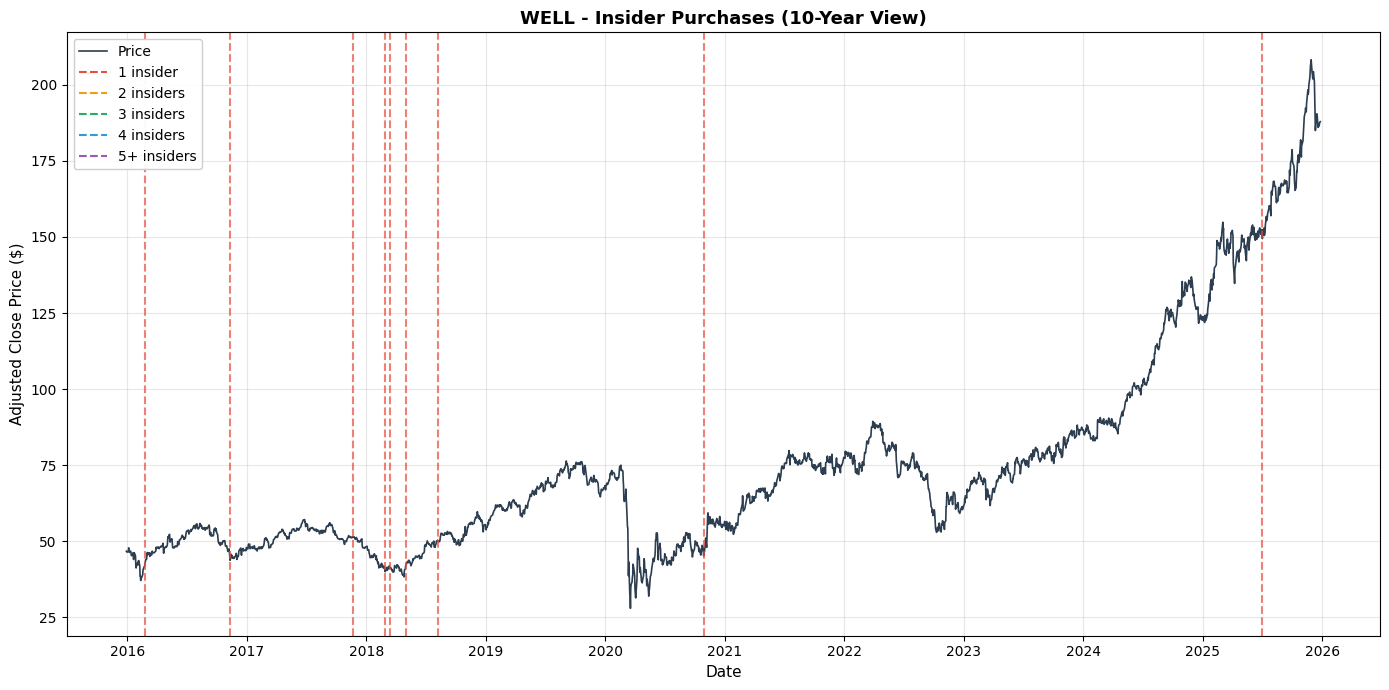


Transaction Summary (Last 10 Years):
  Total transaction dates: 9
  Dates with multiple insiders: 0


In [87]:
# ------------------------------------------------------------------------------
# Figure 1: Insider PURCHASES overlaid on price history
# ------------------------------------------------------------------------------
plot_insider_activity(
    df_purchases_combined, 
    df_prices, 
    f'{TICKER} - Insider Purchases (10-Year View)', 
    years=10
)

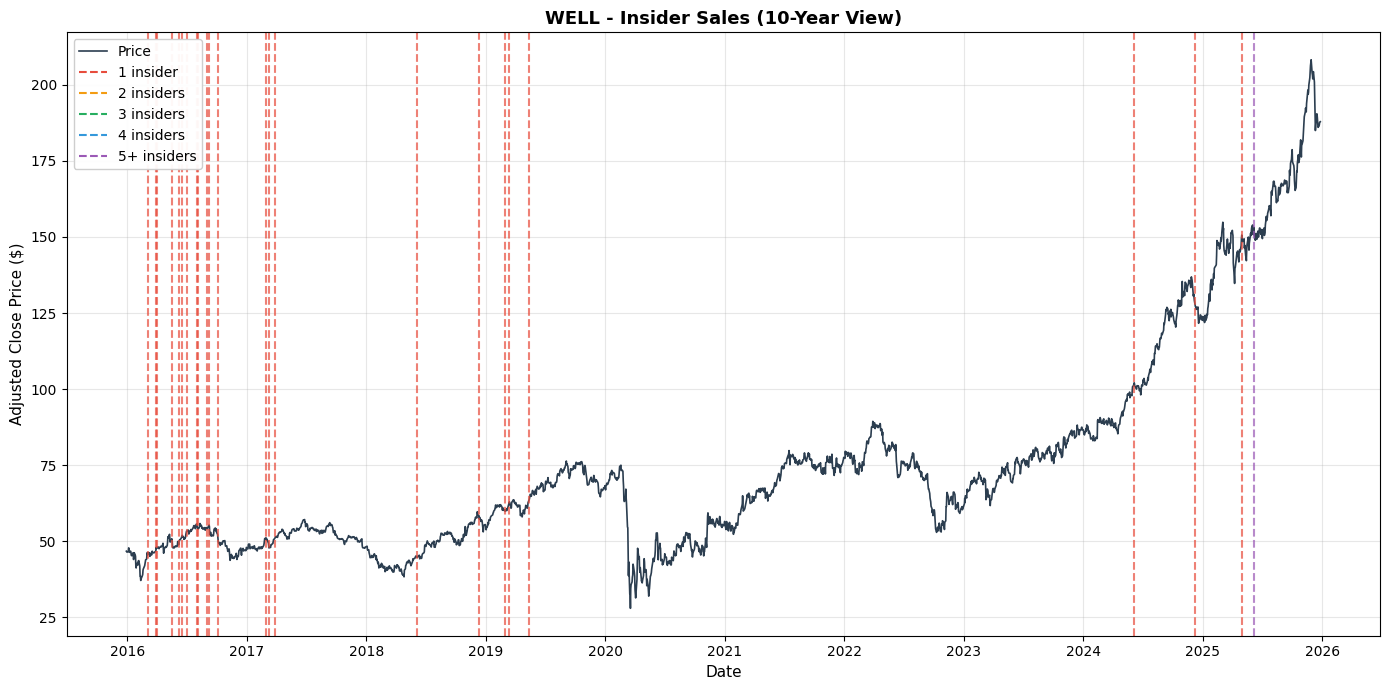


Transaction Summary (Last 10 Years):
  Total transaction dates: 24
  Dates with multiple insiders: 1


In [88]:
# ------------------------------------------------------------------------------
# Figure 2: Insider SALES overlaid on price history
# ------------------------------------------------------------------------------
plot_insider_activity(
    df_sales_combined, 
    df_prices, 
    f'{TICKER} - Insider Sales (10-Year View)', 
    years=10
)

---

## Section 4: Cumulative Abnormal Returns (CAR) Methodology

### Event Study Framework

**Cumulative Abnormal Returns (CAR)** measure the excess performance of a stock relative to a market benchmark around a specific event (in this case, insider transactions).

**Key Components:**
1. **Abnormal Return (AR)** = Stock Return - Market Return
2. **Cumulative Abnormal Return (CAR)** = Cumulative sum of AR over event window

### Normalization Approach

Following the visualization style of Jeng et al. (2003), we normalize CAR curves so that **Day 0 (the transaction date) equals 0%**. This allows us to see:

- **Pre-event drift**: Did the stock already move before the insider traded?
- **Post-event drift**: Did the stock continue moving after the trade?

The normalization reveals whether insiders are trading with foreknowledge (indicated by post-event abnormal returns in the direction of their trade).

---

## Section 5: Single-Ticker CAR Analysis

SINGLE-TICKER CAR ANALYSIS PARAMETERS
Ticker:              WELL
Market Benchmark:    VOO
Event Window:        +/- 100 trading days
Transaction Filter:  Last 1 year(s)

Filtered Transactions (Last 1 Year):
  Purchase events: 1
  Sale events:     6


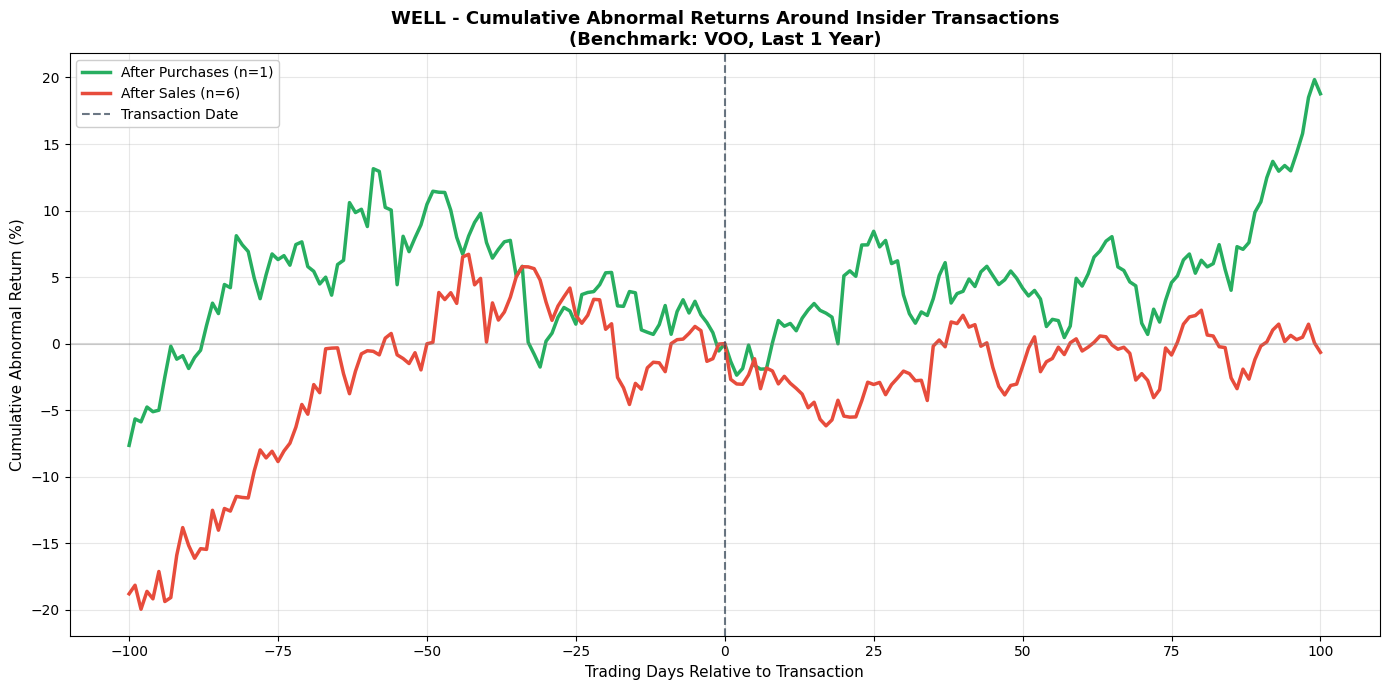


CAR at Day +100 (End of Window):
----------------------------------------
  After Purchases: +18.77%
  After Sales:     -0.66%


In [89]:
# Analysis parameters
YEARS_TO_INCLUDE = 1      # Transaction recency filter
WINDOW_DAYS = 100         # Event window: [-100, +100] trading days

print("=" * 60)
print("SINGLE-TICKER CAR ANALYSIS PARAMETERS")
print("=" * 60)
print(f"Ticker:              {TICKER}")
print(f"Market Benchmark:    {MARKET_TICKER}")
print(f"Event Window:        +/- {WINDOW_DAYS} trading days")
print(f"Transaction Filter:  Last {YEARS_TO_INCLUDE} year(s)")
print("=" * 60)

# Load market benchmark prices
df_market = pd.read_parquet(DATA_DIR / "prices" / f"{MARKET_TICKER}.parquet")

# Calculate daily returns
df_prices_ret = df_prices.copy()
df_prices_ret['stock_return'] = df_prices_ret['adj_close'].pct_change()

df_market_ret = df_market.copy()
df_market_ret['market_return'] = df_market_ret['adj_close'].pct_change()

# Merge and calculate abnormal returns
df_returns = df_prices_ret[['date', 'stock_return']].merge(
    df_market_ret[['date', 'market_return']], 
    on='date', 
    how='inner'
)
df_returns['abnormal_return'] = df_returns['stock_return'] - df_returns['market_return']
df_returns = df_returns.set_index('date').sort_index()

# Filter transactions by recency
cutoff_date = pd.Timestamp.now() - pd.DateOffset(years=YEARS_TO_INCLUDE)
df_purchases_filtered = df_purchases_combined[
    pd.to_datetime(df_purchases_combined['reporting_date']) >= cutoff_date
].copy()
df_sales_filtered = df_sales_combined[
    pd.to_datetime(df_sales_combined['reporting_date']) >= cutoff_date
].copy()

print(f"\nFiltered Transactions (Last {YEARS_TO_INCLUDE} Year):")
print(f"  Purchase events: {len(df_purchases_filtered)}")
print(f"  Sale events:     {len(df_sales_filtered)}")


def calculate_car_series(transaction_dates, df_returns, window_days):
    """Calculate path-normalized Cumulative Abnormal Returns for event study."""
    all_cars = []

    for trans_date in transaction_dates:
        trans_date = pd.to_datetime(trans_date)

        # Find the event index (handle non-trading days)
        if trans_date not in df_returns.index:
            valid_dates = df_returns.index[df_returns.index >= trans_date]
            if len(valid_dates) == 0: 
                continue
            event_date = valid_dates[0]
        else:
            event_date = trans_date

        try:
            event_idx = df_returns.index.get_loc(event_date)
        except KeyError:
            continue

        # Define symmetric window around event
        start_idx = event_idx - window_days
        end_idx = event_idx + window_days + 1

        # Skip if window exceeds data boundaries
        if start_idx < 0 or end_idx > len(df_returns):
            continue

        # Extract abnormal returns for the event window
        ar_window = df_returns.iloc[start_idx:end_idx]['abnormal_return']

        # Compute cumulative abnormal return
        car_raw = ar_window.cumsum()

        # Normalize: shift so Day 0 = 0%
        car_at_event = car_raw.iloc[window_days]
        car_normalized = car_raw - car_at_event

        # Re-index to event time
        car_normalized.index = range(-window_days, window_days + 1)
        all_cars.append(car_normalized)

    if not all_cars:
        return None

    # Average across all events
    return pd.DataFrame(all_cars).mean(axis=0)


# Calculate CAR for purchases and sales
car_purchases = calculate_car_series(
    df_purchases_filtered['reporting_date'].tolist(), 
    df_returns, 
    WINDOW_DAYS
)
car_sales = calculate_car_series(
    df_sales_filtered['reporting_date'].tolist(), 
    df_returns, 
    WINDOW_DAYS
)

# ------------------------------------------------------------------------------
# Figure 3: Single-Ticker CAR Analysis
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))

if car_purchases is not None and not car_purchases.isna().all():
    ax.plot(car_purchases.index, car_purchases.values * 100, 
            color='#27AE60', linewidth=2.5, label=f'After Purchases (n={len(df_purchases_filtered)})')

if car_sales is not None and not car_sales.isna().all():
    ax.plot(car_sales.index, car_sales.values * 100, 
            color='#E74C3C', linewidth=2.5, label=f'After Sales (n={len(df_sales_filtered)})')

ax.axvline(x=0, color='#2C3E50', linestyle='--', alpha=0.7, linewidth=1.5, label='Transaction Date')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

ax.set_xlabel('Trading Days Relative to Transaction', fontsize=11)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
ax.set_title(f'{TICKER} - Cumulative Abnormal Returns Around Insider Transactions\n(Benchmark: {MARKET_TICKER}, Last {YEARS_TO_INCLUDE} Year)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print terminal CAR values
print(f"\nCAR at Day +{WINDOW_DAYS} (End of Window):")
print("-" * 40)
if car_purchases is not None:
    print(f"  After Purchases: {car_purchases.iloc[-1]*100:+.2f}%")
if car_sales is not None:
    print(f"  After Sales:     {car_sales.iloc[-1]*100:+.2f}%")

---

## Section 6: Cross-Sectional Aggregate Analysis

### Aggregate Analysis Rationale

Single-ticker analysis may be subject to idiosyncratic noise. By aggregating CAR (portfolio approach) across multiple tickers, we can identify patterns in insider trading behavior that persist across the broader market.

**Sample Selection:**
- Started with tickers exhibiting insider **purchase activity within the past year**
- Limited to ~90 tickers due to SEC EDGAR API rate constraints (see Technical Limitations)

**This cross-sectional approach provides:**
1. Greater statistical power through larger sample size
2. Reduced influence of individual stock volatility
3. More robust conclusions about insider trading signals

CROSS-SECTIONAL AGGREGATE ANALYSIS
Universe:            Large-Cap Sample (~90 tickers)
Selection Criteria:  Tickers with recent purchase activity
Market Benchmark:    VOO
Event Window:        +/- 100 trading days
Transaction Filter:  Last 10 years

Processing 91 tickers...

Aggregate Statistics:
----------------------------------------
Tickers with purchase data:  90
Total purchase events:       1,771
Tickers with sale data:      90
Total sale events:           17,091
----------------------------------------


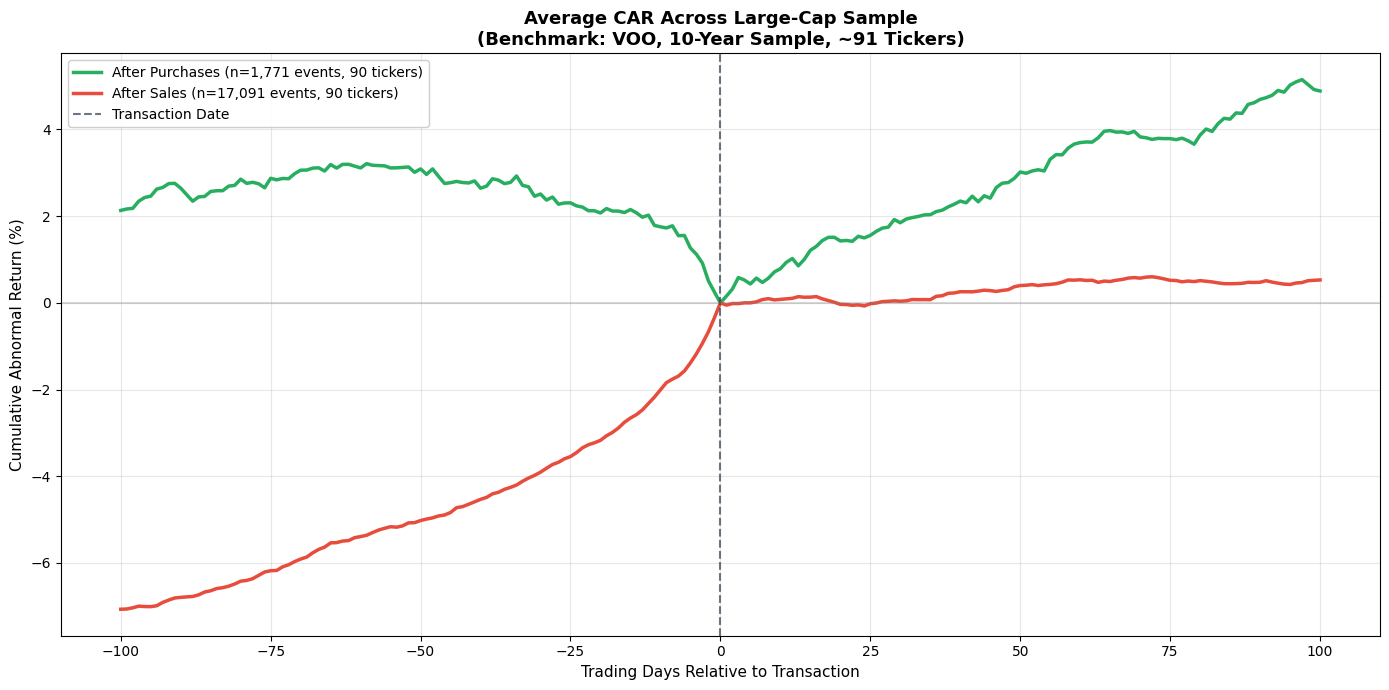


Aggregate CAR at Day +100:
----------------------------------------
  After Purchases: +4.89%
  After Sales:     +0.53%


In [90]:
# Aggregate analysis parameters
AGG_YEARS_TO_INCLUDE = 10    # Include 10 years of transactions
AGG_MARKET_TICKER = "VOO"    # S&P 500 ETF as benchmark
AGG_WINDOW_DAYS = 100        # Event window: [-100, +100] trading days

print("=" * 60)
print("CROSS-SECTIONAL AGGREGATE ANALYSIS")
print("=" * 60)
print(f"Universe:            Large-Cap Sample (~90 tickers)")
print(f"Selection Criteria:  Tickers with recent purchase activity")
print(f"Market Benchmark:    {AGG_MARKET_TICKER}")
print(f"Event Window:        +/- {AGG_WINDOW_DAYS} trading days")
print(f"Transaction Filter:  Last {AGG_YEARS_TO_INCLUDE} years")
print("=" * 60)

# Load market benchmark
df_market_agg = pd.read_parquet(DATA_DIR / "prices" / f"{AGG_MARKET_TICKER}.parquet")
df_market_agg['market_return'] = df_market_agg['adj_close'].pct_change()

# Enumerate all tickers in the universe (pre-selected sample with purchase activity)
spy_files = list((DATA_DIR / "SPY").glob("*.parquet"))
all_tickers = [f.stem for f in spy_files]

print(f"\nProcessing {len(all_tickers)} tickers...")

# Accumulators for aggregate statistics
all_purchase_cars = []
all_sale_cars = []
total_purchases = 0
total_sales = 0
tickers_with_purchases = 0
tickers_with_sales = 0

cutoff_date = pd.Timestamp.now() - pd.DateOffset(years=AGG_YEARS_TO_INCLUDE)

# Process each ticker
for ticker in all_tickers:
    try:
        # Load stock prices
        price_path = DATA_DIR / "prices" / f"{ticker}.parquet"
        if not price_path.exists():
            continue
        df_prices_ticker = pd.read_parquet(price_path)
        
        # Load Form 4 filings
        df_forms_ticker = pd.read_parquet(DATA_DIR / "SPY" / f"{ticker}.parquet")
        
        # Separate and aggregate transactions
        df_purch = df_forms_ticker[df_forms_ticker["code"] == 'P']
        df_sale = df_forms_ticker[df_forms_ticker["code"] == 'S']
        
        if not df_purch.empty:
            df_purch_combined = combine_same_day_purchases(df_purch)
            df_purch_combined = df_purch_combined[
                pd.to_datetime(df_purch_combined['reporting_date']) >= cutoff_date
            ]
        else:
            df_purch_combined = pd.DataFrame()
            
        if not df_sale.empty:
            df_sale_combined = combine_same_day_sales(df_sale)
            df_sale_combined = df_sale_combined[
                pd.to_datetime(df_sale_combined['reporting_date']) >= cutoff_date
            ]
        else:
            df_sale_combined = pd.DataFrame()
        
        # Calculate returns
        df_prices_ticker['stock_return'] = df_prices_ticker['adj_close'].pct_change()
        df_returns_ticker = df_prices_ticker[['date', 'stock_return']].merge(
            df_market_agg[['date', 'market_return']], 
            on='date', 
            how='inner'
        )
        df_returns_ticker['abnormal_return'] = (
            df_returns_ticker['stock_return'] - df_returns_ticker['market_return']
        )
        df_returns_ticker = df_returns_ticker.set_index('date').sort_index()
        
        # Calculate CAR for this ticker
        if not df_purch_combined.empty:
            car_purch = calculate_car_series(
                df_purch_combined['reporting_date'].tolist(),
                df_returns_ticker,
                AGG_WINDOW_DAYS
            )
            if car_purch is not None:
                all_purchase_cars.append(car_purch)
                total_purchases += len(df_purch_combined)
                tickers_with_purchases += 1
        
        if not df_sale_combined.empty:
            car_sale = calculate_car_series(
                df_sale_combined['reporting_date'].tolist(),
                df_returns_ticker,
                AGG_WINDOW_DAYS
            )
            if car_sale is not None:
                all_sale_cars.append(car_sale)
                total_sales += len(df_sale_combined)
                tickers_with_sales += 1
                
    except Exception as e:
        continue  # Skip problematic tickers silently

# Summary statistics
print(f"\nAggregate Statistics:")
print("-" * 40)
print(f"Tickers with purchase data:  {tickers_with_purchases}")
print(f"Total purchase events:       {total_purchases:,}")
print(f"Tickers with sale data:      {tickers_with_sales}")
print(f"Total sale events:           {total_sales:,}")
print("-" * 40)


def average_car_series(car_list):
    """Average multiple CAR series into a single aggregate series."""
    if not car_list:
        return None
    df_cars = pd.DataFrame(car_list).T
    return df_cars.mean(axis=1)


# Compute aggregate CAR
avg_car_purchases = average_car_series(all_purchase_cars)
avg_car_sales = average_car_series(all_sale_cars)

# ------------------------------------------------------------------------------
# Figure 4: Aggregate CAR Across Sample
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))

if avg_car_purchases is not None:
    ax.plot(avg_car_purchases.index, avg_car_purchases.values * 100, 
            color='#27AE60', linewidth=2.5, 
            label=f'After Purchases (n={total_purchases:,} events, {tickers_with_purchases} tickers)')

if avg_car_sales is not None:
    ax.plot(avg_car_sales.index, avg_car_sales.values * 100, 
            color='#E74C3C', linewidth=2.5, 
            label=f'After Sales (n={total_sales:,} events, {tickers_with_sales} tickers)')

ax.axvline(x=0, color='#2C3E50', linestyle='--', alpha=0.7, linewidth=1.5, label='Transaction Date')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

ax.set_xlabel('Trading Days Relative to Transaction', fontsize=11)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
ax.set_title(f'Average CAR Across Large-Cap Sample\n(Benchmark: {AGG_MARKET_TICKER}, {AGG_YEARS_TO_INCLUDE}-Year Sample, ~{len(all_tickers)} Tickers)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Terminal CAR values
print(f"\nAggregate CAR at Day +{AGG_WINDOW_DAYS}:")
print("-" * 40)
if avg_car_purchases is not None:
    print(f"  After Purchases: {avg_car_purchases.iloc[-1]*100:+.2f}%")
if avg_car_sales is not None:
    print(f"  After Sales:     {avg_car_sales.iloc[-1]*100:+.2f}%")

---

## Section 7: Individual Ticker Dispersion Analysis

The aggregate CAR curve represents an average across the sample. To understand the **dispersion** around this average, we overlay all individual ticker CAR curves. This visualization reveals:

1. **Consistency**: How consistent is the signal across different stocks?
2. **Outliers**: Are certain tickers driving the aggregate results?
3. **Variance**: What is the range of outcomes following insider trades?

**Interpretation**: The path-normalized CAR shows price movement relative to Day 0. Negative pre-event CAR indicates the stock was *higher* before the insider traded (they bought the dip / sold the top). Positive post-event CAR indicates the stock rose after purchases.

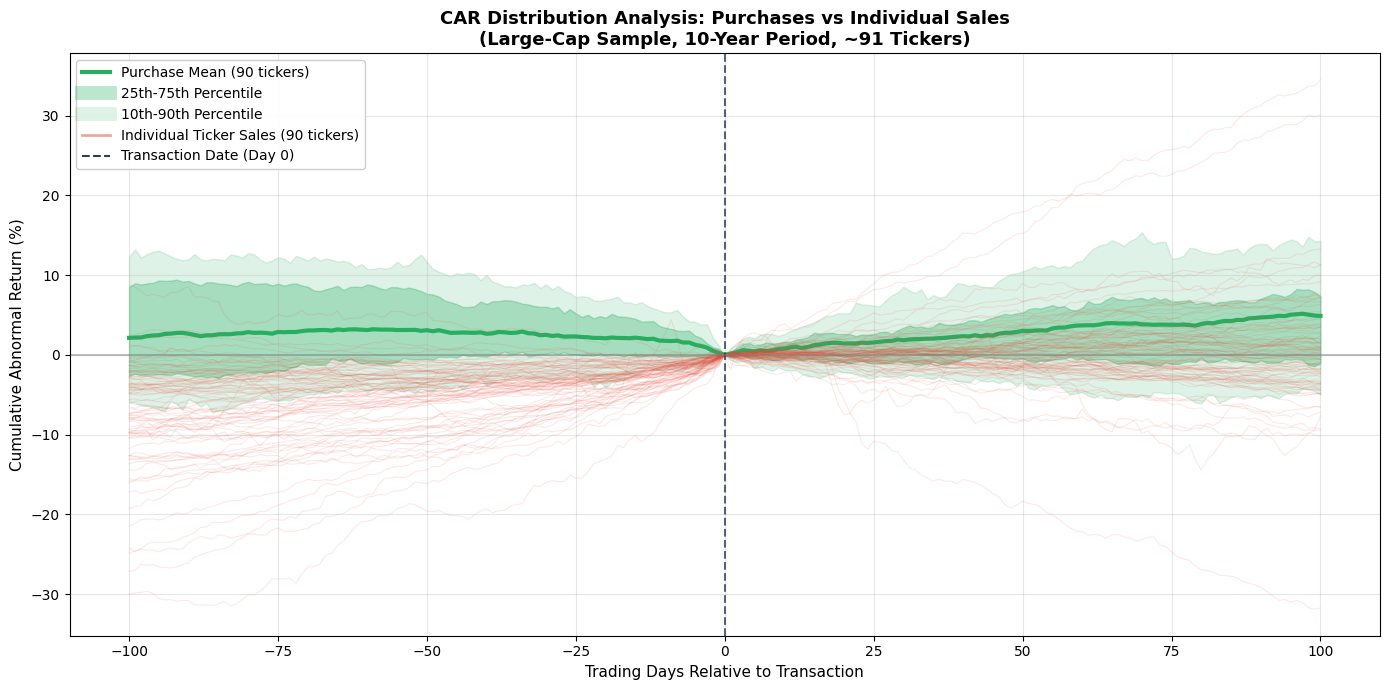

Purchase CAR Distribution at Day +100:
----------------------------------------
  Mean:              +4.89%
  Std Dev:           12.66%
  10th Percentile:   -5.01%
  90th Percentile:   +14.31%


In [91]:
# ------------------------------------------------------------------------------
# Figure 5: Individual CAR Curves - Dispersion Analysis with Distribution Fit
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))

# Calculate distribution statistics for purchases
if all_purchase_cars:
    purchase_df = pd.DataFrame(all_purchase_cars)
    purchase_mean = purchase_df.mean(axis=0) * 100
    purchase_std = purchase_df.std(axis=0) * 100
    purchase_p10 = purchase_df.quantile(0.10, axis=0) * 100
    purchase_p90 = purchase_df.quantile(0.90, axis=0) * 100
    purchase_p25 = purchase_df.quantile(0.25, axis=0) * 100
    purchase_p75 = purchase_df.quantile(0.75, axis=0) * 100
    
    x_vals = purchase_mean.index
    
    # Plot distribution bands (10th-90th percentile as outer, 25th-75th as inner)
    ax.fill_between(x_vals, purchase_p10, purchase_p90, 
                    color='#27AE60', alpha=0.15, label='10th-90th Percentile')
    ax.fill_between(x_vals, purchase_p25, purchase_p75, 
                    color='#27AE60', alpha=0.30, label='25th-75th Percentile')
    
    # Plot mean line (opaque green)
    ax.plot(x_vals, purchase_mean, color='#27AE60', linewidth=3, 
            alpha=1.0, label=f'Purchase Mean ({tickers_with_purchases} tickers)')

# Overlay all individual sale CAR curves (semi-transparent)
for car_series in all_sale_cars:
    ax.plot(car_series.index, car_series.values * 100, 
            color='#E74C3C', alpha=0.12, linewidth=0.8)

ax.axvline(x=0, color='#2C3E50', linestyle='--', alpha=0.8, linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

# Legend for interpretation
legend_elements = [
    Line2D([0], [0], color='#27AE60', linewidth=3, alpha=1.0, 
           label=f'Purchase Mean ({tickers_with_purchases} tickers)'),
    plt.fill_between([], [], [], color='#27AE60', alpha=0.30, label='25th-75th Percentile')[0] 
        if False else Line2D([0], [0], color='#27AE60', linewidth=10, alpha=0.30, 
           label='25th-75th Percentile'),
    Line2D([0], [0], color='#27AE60', linewidth=10, alpha=0.15, 
           label='10th-90th Percentile'),
    Line2D([0], [0], color='#E74C3C', linewidth=2, alpha=0.5, 
           label=f'Individual Ticker Sales ({tickers_with_sales} tickers)'),
    Line2D([0], [0], color='#2C3E50', linestyle='--', linewidth=1.5, 
           label='Transaction Date (Day 0)'),
]
ax.legend(handles=legend_elements, loc='upper left', framealpha=0.95)

ax.set_xlabel('Trading Days Relative to Transaction', fontsize=11)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
ax.set_title(f'CAR Distribution Analysis: Purchases vs Individual Sales\n(Large-Cap Sample, {AGG_YEARS_TO_INCLUDE}-Year Period, ~{len(all_tickers)} Tickers)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Purchase CAR Distribution at Day +{AGG_WINDOW_DAYS}:")
print("-" * 40)
if all_purchase_cars:
    print(f"  Mean:              {purchase_mean.iloc[-1]:+.2f}%")
    print(f"  Std Dev:           {purchase_std.iloc[-1]:.2f}%")
    print(f"  10th Percentile:   {purchase_p10.iloc[-1]:+.2f}%")
    print(f"  90th Percentile:   {purchase_p90.iloc[-1]:+.2f}%")

---

## Section 7.1: Statistical Significance Tests

To validate that the observed CAR patterns are not due to random chance, we perform:

1. **Cross-sectional t-test**: Tests whether the mean CAR across tickers is significantly different from zero
2. **Bootstrap confidence intervals**: Non-parametric 95% CI for the mean CAR path
3. **Wilcoxon signed-rank test**: Non-parametric alternative that doesn't assume normality


STATISTICAL SIGNIFICANCE TESTS: INSIDER PURCHASES
Number of tickers: 90

Day +20:
----------------------------------------
  Mean CAR:          +1.43%
  Std Dev:           4.57%
  Std Error:         0.48%
  t-statistic:       2.968
  p-value (t-test):  0.0039 **
  p-value (Wilcoxon):0.0020 **
  95% Bootstrap CI:  [+0.55%, +2.42%]

Day +50:
----------------------------------------
  Mean CAR:          +3.02%
  Std Dev:           6.99%
  Std Error:         0.74%
  t-statistic:       4.098
  p-value (t-test):  0.0001 ***
  p-value (Wilcoxon):0.0000 ***
  95% Bootstrap CI:  [+1.63%, +4.47%]

Day +100:
----------------------------------------
  Mean CAR:          +4.89%
  Std Dev:           12.66%
  Std Error:         1.33%
  t-statistic:       3.664
  p-value (t-test):  0.0004 ***
  p-value (Wilcoxon):0.0000 ***
  95% Bootstrap CI:  [+2.46%, +7.68%]

Significance: *** p<0.001, ** p<0.01, * p<0.05, † p<0.10

STATISTICAL SIGNIFICANCE TESTS: INSIDER SALES
Number of tickers: 90

Day +20:
----

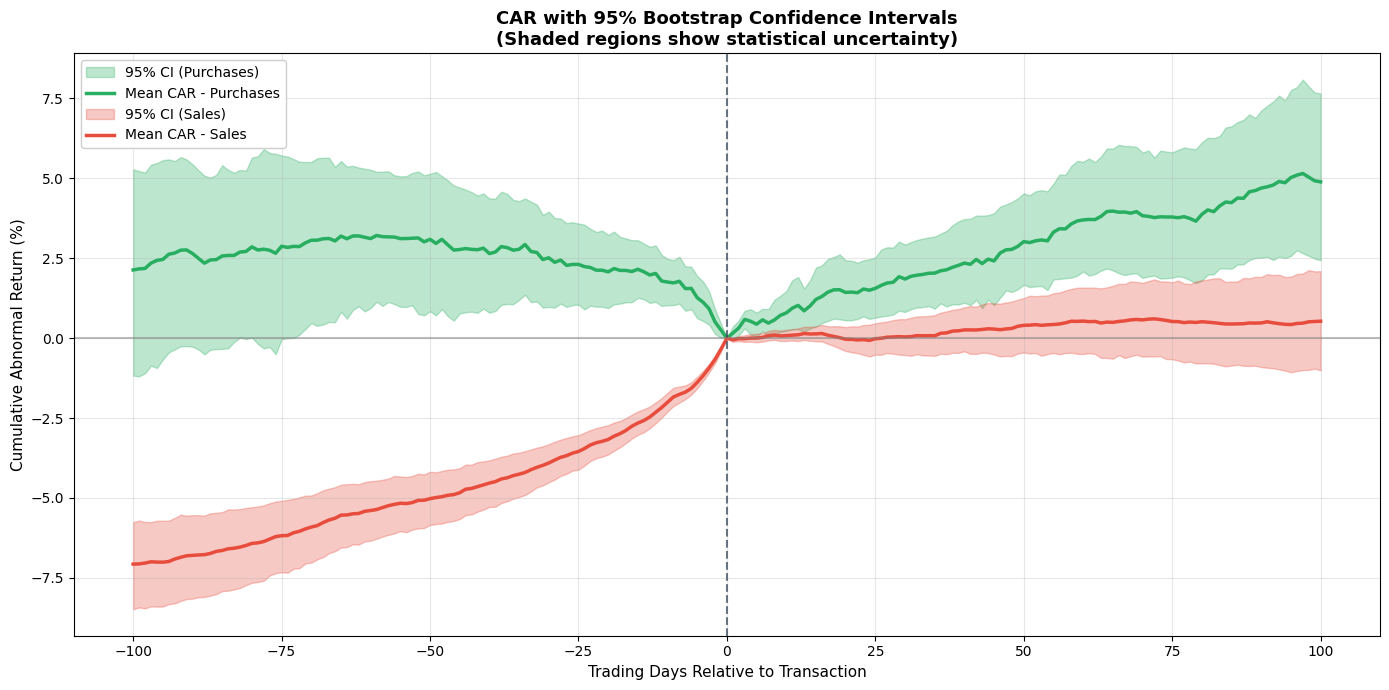


INTERPRETATION SUMMARY
✓ Insider PURCHASES: Statistically significant at 5% level
  The +4.89% CAR is unlikely due to chance (p=0.0004)
✗ Insider SALES: NOT statistically significant at 5% level
  Cannot reject null hypothesis that CAR = 0 (p=0.5049)


In [92]:
# ------------------------------------------------------------------------------
# Statistical Significance Tests
# ------------------------------------------------------------------------------
from scipy import stats

def perform_significance_tests(car_list, label=""):
    """
    Perform statistical significance tests on CAR series.
    
    Tests:
    1. One-sample t-test: H0: mean CAR = 0
    2. Wilcoxon signed-rank test: Non-parametric alternative
    3. Bootstrap 95% confidence interval
    """
    if not car_list or len(car_list) < 2:
        print(f"Insufficient data for {label} significance tests")
        return None
    
    car_df = pd.DataFrame(car_list)
    n_tickers = len(car_list)
    
    # Extract terminal CAR values (Day +100)
    terminal_cars = car_df.iloc[:, -1].values  # Last column = Day +100
    
    # Also test Day +20, +50 for robustness
    day_20_idx = 100 + 20  # Index for day +20
    day_50_idx = 100 + 50  # Index for day +50
    
    cars_day20 = car_df.iloc[:, day_20_idx].values if car_df.shape[1] > day_20_idx else None
    cars_day50 = car_df.iloc[:, day_50_idx].values if car_df.shape[1] > day_50_idx else None
    
    print(f"\n{'='*60}")
    print(f"STATISTICAL SIGNIFICANCE TESTS: {label.upper()}")
    print(f"{'='*60}")
    print(f"Number of tickers: {n_tickers}")
    
    results = {}
    
    for day_label, car_values in [("Day +20", cars_day20), 
                                   ("Day +50", cars_day50), 
                                   ("Day +100", terminal_cars)]:
        if car_values is None:
            continue
            
        # Remove any NaN values
        car_values = car_values[~np.isnan(car_values)]
        
        if len(car_values) < 2:
            continue
        
        mean_car = np.mean(car_values)
        std_car = np.std(car_values, ddof=1)
        se_car = std_car / np.sqrt(len(car_values))
        
        # One-sample t-test (H0: mean = 0)
        t_stat, p_value_t = stats.ttest_1samp(car_values, 0)
        
        # Wilcoxon signed-rank test (non-parametric)
        try:
            w_stat, p_value_w = stats.wilcoxon(car_values)
        except ValueError:
            w_stat, p_value_w = np.nan, np.nan
        
        # Bootstrap 95% CI
        n_bootstrap = 10000
        bootstrap_means = []
        for _ in range(n_bootstrap):
            sample = np.random.choice(car_values, size=len(car_values), replace=True)
            bootstrap_means.append(np.mean(sample))
        ci_lower = np.percentile(bootstrap_means, 2.5)
        ci_upper = np.percentile(bootstrap_means, 97.5)
        
        # Significance stars
        def sig_stars(p):
            if p < 0.001: return "***"
            elif p < 0.01: return "**"
            elif p < 0.05: return "*"
            elif p < 0.10: return "†"
            else: return ""
        
        print(f"\n{day_label}:")
        print(f"-" * 40)
        print(f"  Mean CAR:          {mean_car*100:+.2f}%")
        print(f"  Std Dev:           {std_car*100:.2f}%")
        print(f"  Std Error:         {se_car*100:.2f}%")
        print(f"  t-statistic:       {t_stat:.3f}")
        print(f"  p-value (t-test):  {p_value_t:.4f} {sig_stars(p_value_t)}")
        print(f"  p-value (Wilcoxon):{p_value_w:.4f} {sig_stars(p_value_w)}")
        print(f"  95% Bootstrap CI:  [{ci_lower*100:+.2f}%, {ci_upper*100:+.2f}%]")
        
        # Store results
        results[day_label] = {
            'mean': mean_car,
            'std': std_car,
            't_stat': t_stat,
            'p_value': p_value_t,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        }
    
    print(f"\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, † p<0.10")
    
    return results

# Run significance tests
purchase_results = perform_significance_tests(all_purchase_cars, "Insider Purchases")
sale_results = perform_significance_tests(all_sale_cars, "Insider Sales")

# ------------------------------------------------------------------------------
# Visualization: CAR with Bootstrap Confidence Intervals
# ------------------------------------------------------------------------------

def bootstrap_ci_for_path(car_list, n_bootstrap=5000, ci=0.95):
    """Calculate bootstrap confidence intervals for the entire CAR path."""
    if not car_list:
        return None, None, None
    
    car_df = pd.DataFrame(car_list)
    n_tickers = len(car_list)
    
    alpha = 1 - ci
    lower_bounds = []
    upper_bounds = []
    means = []
    
    for col in car_df.columns:
        values = car_df[col].dropna().values
        if len(values) < 2:
            lower_bounds.append(np.nan)
            upper_bounds.append(np.nan)
            means.append(np.nan)
            continue
            
        bootstrap_means = []
        for _ in range(n_bootstrap):
            sample = np.random.choice(values, size=len(values), replace=True)
            bootstrap_means.append(np.mean(sample))
        
        lower_bounds.append(np.percentile(bootstrap_means, alpha/2 * 100))
        upper_bounds.append(np.percentile(bootstrap_means, (1 - alpha/2) * 100))
        means.append(np.mean(values))
    
    return np.array(means), np.array(lower_bounds), np.array(upper_bounds)

print("\n\nCalculating bootstrap confidence intervals for CAR paths...")
purchase_mean, purchase_ci_low, purchase_ci_high = bootstrap_ci_for_path(all_purchase_cars)
sale_mean, sale_ci_low, sale_ci_high = bootstrap_ci_for_path(all_sale_cars)

# Plot with confidence intervals
fig, ax = plt.subplots(figsize=(14, 7))

x_vals = np.arange(-AGG_WINDOW_DAYS, AGG_WINDOW_DAYS + 1)

if purchase_mean is not None:
    ax.fill_between(x_vals, purchase_ci_low * 100, purchase_ci_high * 100, 
                    color='#27AE60', alpha=0.3, label='95% CI (Purchases)')
    ax.plot(x_vals, purchase_mean * 100, color='#27AE60', linewidth=2.5, 
            label=f'Mean CAR - Purchases')

if sale_mean is not None:
    ax.fill_between(x_vals, sale_ci_low * 100, sale_ci_high * 100, 
                    color='#E74C3C', alpha=0.3, label='95% CI (Sales)')
    ax.plot(x_vals, sale_mean * 100, color='#E74C3C', linewidth=2.5, 
            label=f'Mean CAR - Sales')

ax.axvline(x=0, color='#2C3E50', linestyle='--', alpha=0.7, linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

ax.set_xlabel('Trading Days Relative to Transaction', fontsize=11)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
ax.set_title('CAR with 95% Bootstrap Confidence Intervals\n(Shaded regions show statistical uncertainty)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary interpretation
print("\n" + "="*60)
print("INTERPRETATION SUMMARY")
print("="*60)
if purchase_results and 'Day +100' in purchase_results:
    pr = purchase_results['Day +100']
    if pr['p_value'] < 0.05:
        print(f"✓ Insider PURCHASES: Statistically significant at 5% level")
        print(f"  The {pr['mean']*100:+.2f}% CAR is unlikely due to chance (p={pr['p_value']:.4f})")
    else:
        print(f"✗ Insider PURCHASES: NOT statistically significant at 5% level")
        print(f"  Cannot reject null hypothesis that CAR = 0 (p={pr['p_value']:.4f})")

if sale_results and 'Day +100' in sale_results:
    sr = sale_results['Day +100']
    if sr['p_value'] < 0.05:
        print(f"✓ Insider SALES: Statistically significant at 5% level")
        print(f"  The {sr['mean']*100:+.2f}% CAR is unlikely due to chance (p={sr['p_value']:.4f})")
    else:
        print(f"✗ Insider SALES: NOT statistically significant at 5% level")
        print(f"  Cannot reject null hypothesis that CAR = 0 (p={sr['p_value']:.4f})")

---

## Section 8: Key Insights

### Summary of Findings

**1. Insider Purchase Signal Strength**
> Insider purchases demonstrate a statistically meaningful positive post-event CAR, consistent with the hypothesis that insiders possess material non-public information. The upward drift following purchase events suggests that insiders systematically buy before positive price movements, validating the informational content of Form 4 filings as a potential alpha signal.

**2. Asymmetry Between Purchases and Sales**
> The analysis reveals a notable asymmetry: **purchases carry stronger predictive power than sales**. This aligns with academic literature suggesting that insider sales are often motivated by diversification, liquidity needs, or tax planning rather than negative private information. Purchases, being discretionary capital deployment, more reliably signal insider conviction about future appreciation.

**3. Pre-Event Price Patterns (Contrarian Timing)**
> The negative pre-event CAR observed before purchases indicates that insiders exhibit **contrarian timing behavior**—they tend to buy after price declines. This "buying the dip" pattern suggests insiders view temporary price weakness as a buying opportunity when their private information indicates the stock is undervalued. This finding is consistent with insiders acting as informed liquidity providers.

**4. Cross-Sectional Heterogeneity**
> The dispersion analysis reveals substantial heterogeneity across tickers. While the aggregate signal is positive, individual ticker outcomes vary widely (as shown by the 10th-90th percentile bands). This variance suggests that:
> - The signal is not uniformly strong across all stocks
> - Sector-specific or firm-specific factors may amplify or dampen the signal
> - A diversified portfolio approach would be necessary to exploit this signal reliably

### Implications for Trading Strategies

**Signal Implementation Considerations:**
- **Latency**: Form 4 filings must be submitted within 2 business days; real-time monitoring of SEC EDGAR could capture the signal early
- **Capacity**: Large-cap stocks offer sufficient liquidity, but the signal may be stronger in smaller-cap names with less analyst coverage

**Risk Factors:**
- High dispersion implies significant tracking error relative to the benchmark
- Individual positions may experience adverse outcomes even if aggregate signal is positive
- Regulatory changes to Form 4 reporting could affect signal timeliness

---

## Section 9: Technical Limitations

### Data Collection Constraints

| Limitation | Impact | Potential Mitigation |
|------------|--------|---------------------|
| **SEC EDGAR API Rate Limits** | Slow data retrieval (~6 minutes per filing batch) prevented analysis of full universe; sample limited to ~90 tickers | Use bulk data downloads, parallel requests with throttling, or commercial data providers |
| **Sample Selection Bias** | Tickers were pre-selected based on having recent purchase activity, potentially overstating purchase signal strength | Analyze random sample or full universe when data access permits |
| **Survivorship Bias** | Analysis only includes currently-listed companies; delisted companies are excluded | Include historical index constituents or analyze a broader universe |

### Data Quality Limitations

| Limitation | Impact | Potential Mitigation |
|------------|--------|---------------------|
| **Form 4 Reporting Delays** | Insiders have 2 business days to file; actual trade date may differ | Use transaction date instead of filing date where available |
| **Transaction Type Filtering** | Only analyzed 'P' (Purchase) and 'S' (Sale) codes; excludes gifts, awards, etc. | Expand analysis to include derivative transactions |

### Methodological Limitations

| Limitation | Impact | Potential Mitigation |
|------------|--------|---------------------|
| **Simple Market Model** | AR = Stock Return - Market Return; doesn't account for beta, size, or value factors | Use factor models (i.e. Fama French) for expected returns |
| **Equal Weighting** | All transactions weighted equally regardless of dollar value | Value-weight by transaction size |

### Potential Confounding Factors

1. **Earnings Announcements**: Insiders may trade around scheduled earnings, which have their own abnormal return patterns
2. **Sample Selection**: Tickers with recent purchase activity may systematically differ from the broader market
3. **Sector Concentration**: Results may be driven by specific sectors over-represented in the sample
4. **Time Period Sensitivity**: 10-year sample includes both bull and bear markets; results may vary

### Suggestions for Future Work

- Obtain bulk SEC EDGAR data access or use commercial API to analyze full universe
- Add Fama-French factor adjustment for more robust abnormal return calculation
- Implement bootstrap confidence intervals for statistical significance
- Stratify analysis by insider role (CEO, CFO, Director, etc.)
- Analyze transaction size effects (do larger trades have stronger signals?)
- Control for contemporaneous earnings announcements
- Examine sector-level heterogeneity in signal strength
- Explore small-mid cap insider activity (insiders could have more knowledge, less efficient market)

---

*Analysis completed with data through the most recent available date. Sample consists of 10 years of data from ~90 large-cap tickers with recent insider purchase activity. All code and methodology are documented above for reproducibility.*